In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Cargar la base
df = pd.read_excel("/Users/karlavega/Proyectos/Colaborativos/Forest_Peru/Datos/BD/resultados_turnover_2022_con_delitos.xlsx")


In [8]:

# 2. Definir variables
y_col = "delitos_suma_2023_2025"     # criminalidad
D_col = "turnover_org"               # tratamiento solicitado
Z_col = "orden_aparicion"            # instrumento
prov_col = "provincia"               # FE por provincia

# 3. Construir dataset base
df_model = df[[y_col, D_col, Z_col, prov_col]].copy()

# 4. LOG del outcome – agregar 1 para evitar log(0)
df_model["log_y"] = np.log(df_model[y_col] + 1)

# 5. Asegurar tipos numéricos
for col in [D_col, Z_col, "log_y"]:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

df_model = df_model.dropna()

# 6. Crear FE por provincia
prov_dummies = pd.get_dummies(df_model[prov_col], prefix="prov", drop_first=True)

# 7. Definir variables
y = df_model["log_y"].astype(float)
D = df_model[D_col].astype(float)
Z = df_model[Z_col].astype(float)


In [9]:
# =========================================================
#     PRIMERA ETAPA: turnover_org ~ orden_aparicion + FE provincia
# =========================================================
X1 = pd.concat([Z.rename(Z_col), prov_dummies], axis=1)
X1 = sm.add_constant(X1).astype(float)

first_stage = sm.OLS(D, X1).fit(cov_type='HC1')
df_model["D_hat"] = first_stage.fittedvalues

print("=== PRIMERA ETAPA (FE provincia) ===")
print(first_stage.summary())


=== PRIMERA ETAPA (FE provincia) ===
                            OLS Regression Results                            
Dep. Variable:           turnover_org   R-squared:                       0.160
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.3533
Date:                Sun, 30 Nov 2025   Prob (F-statistic):               1.00
Time:                        13:59:25   Log-Likelihood:                 164.21
No. Observations:                 930   AIC:                            -18.43
Df Residuals:                     775   BIC:                             731.0
Df Model:                         154                                         
Covariance Type:                  HC1                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 154, but rank is 144
  warnings.warn('covariance of constraints does not have full '


In [10]:
# =========================================================
#     SEGUNDA ETAPA: log_y ~ D_hat + FE provincia
# =========================================================
X2 = pd.concat([df_model["D_hat"], prov_dummies], axis=1)
X2 = sm.add_constant(X2).astype(float)

second_stage = sm.OLS(y, X2).fit(cov_type='HC1')

print("\n=== SEGUNDA ETAPA (FE provincia) ===")
print(second_stage.summary())



=== SEGUNDA ETAPA (FE provincia) ===
                            OLS Regression Results                            
Dep. Variable:                  log_y   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.528
Method:                 Least Squares   F-statistic:                 1.254e+04
Date:                Sun, 30 Nov 2025   Prob (F-statistic):               0.00
Time:                        13:59:42   Log-Likelihood:                -1560.6
No. Observations:                 930   AIC:                             3431.
Df Residuals:                     775   BIC:                             4181.
Df Model:                         154                                         
Covariance Type:                  HC1                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 154, but rank is 151
  warnings.warn('covariance of constraints does not have full '


In [12]:
# =========================================================
#     TABLA RESUMEN
# =========================================================
tabla_resumen = pd.DataFrame({
    "etapa": ["primera", "segunda"],
    "variable_clave": [Z_col, "D_hat"],
    "coef": [
        first_stage.params[Z_col],
        second_stage.params["D_hat"]
    ],
    "se_robusta": [
        first_stage.bse[Z_col],
        second_stage.bse["D_hat"]
    ],
    "pvalue": [
        first_stage.pvalues[Z_col],
        second_stage.pvalues["D_hat"]
    ],
    "R2": [
        first_stage.rsquared,
        second_stage.rsquared
    ],
    "N": [
        int(first_stage.nobs),
        int(second_stage.nobs)
    ]
})

print("\n=== TABLA RESUMEN (turnover_org, log_y, FE provincia) ===")
print(tabla_resumen)


=== TABLA RESUMEN (turnover_org, log_y, FE provincia) ===
     etapa   variable_clave      coef  se_robusta    pvalue        R2    N
0  primera  orden_aparicion  0.005120    0.004303  0.234110  0.159744  930
1  segunda            D_hat  4.888067    6.713796  0.466575  0.606521  930


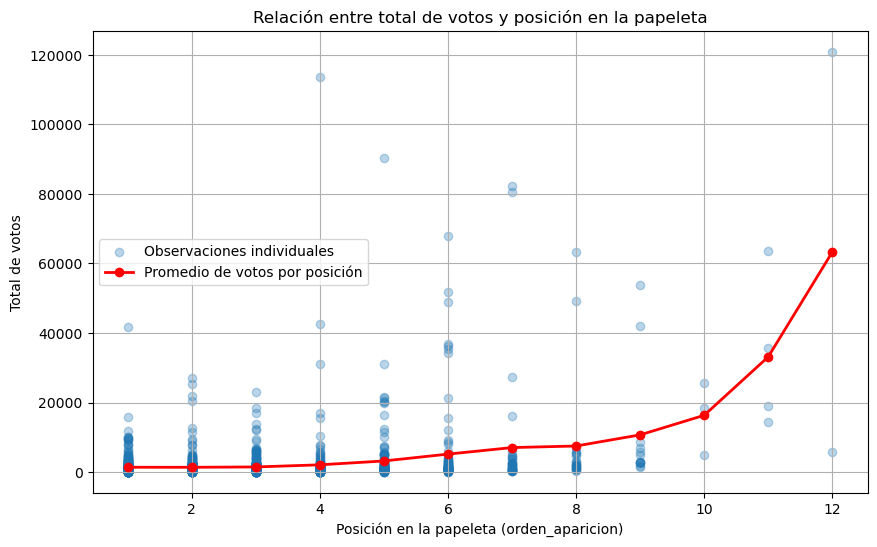

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
# Asegurar variables numéricas
df["total_votos"] = pd.to_numeric(df["total_votos"], errors="coerce")
df["orden_aparicion"] = pd.to_numeric(df["orden_aparicion"], errors="coerce")

# Calcular promedio de votos por posición (suavizado)
prom_por_pos = df.groupby("orden_aparicion")["total_votos"].mean().reset_index()

# ------------------------
# Gráfico
# ------------------------

plt.figure(figsize=(10,6))

# Puntos individuales (dispersión)
plt.scatter(df["orden_aparicion"], df["total_votos"], alpha=0.3,
            label="Observaciones individuales")

# Línea de promedio por posición
plt.plot(prom_por_pos["orden_aparicion"], prom_por_pos["total_votos"],
         color="red", marker="o", linewidth=2,
         label="Promedio de votos por posición")

plt.xlabel("Posición en la papeleta (orden_aparicion)")
plt.ylabel("Total de votos")
plt.title("Relación entre total de votos y posición en la papeleta")
plt.grid(True)
plt.legend()
plt.show()